In [47]:
import torch
import numpy as np
from transformers import GPT2Tokenizer, GPT2LMHeadModel
from dotenv import load_dotenv
load_dotenv()

# Load GPT-2 tokenizer and model
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2", output_hidden_states=True)
model.eval()


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [48]:
import numpy as np
from gensim.models import KeyedVectors

try:
    word2vec_model = KeyedVectors.load_word2vec_format(
        'GoogleNews-vectors-negative300.bin', 
        binary=True
    )
except FileNotFoundError:
    print("GoogleNews model not found. Trying gensim's built-in downloader...")
    import gensim.downloader as api
    word2vec_model = api.load("word2vec-google-news-300")


GoogleNews model not found. Trying gensim's built-in downloader...


In [178]:
def get_word_embedding(word, model_str = 'word2vec'):
    """Get embedding vector for a word using GPT-2"""
    if model_str == 'gpt2':
        # Tokenize the word
        tokens = tokenizer.encode(word, add_special_tokens=False)
        
        if not tokens:
            print(f"Warning: Could not tokenize '{word}'")
            return None
        
        if len(tokens) > 1:
            print(f"Warning: '{word}' was tokenized into multiple tokens: {tokens}. Using the first token.")
        
        # Use the first token's embedding
        token_id = tokens[0]
        
        # Get the embedding from the model's token embedding layer
        with torch.no_grad():
            embeddings = model.transformer.wte(torch.tensor([token_id]))[0].numpy()
    else:
        try:
            embeddings = word2vec_model[word]
        except KeyError:
            print(f"Warning: '{word}' not in Word2Vec vocabulary")
            return None

    return embeddings

def get_difference_direction(property_word1, property_word2, model_str = 'word2vec'):
    """Get the difference direction between two property words"""
    emb1 = get_word_embedding(property_word1, model_str=model_str)
    emb2 = get_word_embedding(property_word2, model_str=model_str)

    if emb1 is None or emb2 is None:
        print("Error: Could not get embeddings for both property words")
        return None
    
    # Compute the difference vector
    difference_vector = emb1 - emb2
    return difference_vector

def compare_embeddings(property_word, comparison_word1, comparison_word2, model_str = 'word2vec'):
    """Compare dot products of two words with a property word"""
    
    # Get embeddings
    prop_emb = get_word_embedding(property_word, model_str=model_str)
    diff_embedding = get_difference_direction(comparison_word1, comparison_word2)
    
    if prop_emb is None or diff_embedding is None:
        print("Error: Could not get embeddings for all words")
        return
    
    # Compute dot products
    dot_product_1 = np.dot(prop_emb, diff_embedding) / (np.linalg.norm(prop_emb) * np.linalg.norm(diff_embedding))
    
    print(f"Property word: '{property_word}'")
    print(f"Comparison words: '{comparison_word1} - {comparison_word2}' -> dot product: {dot_product_1:.4f}")
    
    return {
        "property_word": property_word,
        "comparison_word1": comparison_word1,
        "comparison_word2": comparison_word2,
        "dot_product_1": dot_product_1,
    }
property_word = "gender"
comparison_word1 = "man"
comparison_word2 = "woman"
# Example usage
result = compare_embeddings(property_word, comparison_word1, comparison_word2)

Property word: 'gender'
Comparison words: 'man - woman' -> dot product: -0.3264


In [179]:

def compare_embeddings(comparison_word_tuple1, comparison_word_tuple2, model_str = 'word2vec'):
    """Compare dot products of two words with a property word"""
    
    # Get embeddings
    diff_embedding_1 = get_difference_direction(comparison_word_tuple1[0], comparison_word_tuple1[1], model_str=model_str)
    diff_embedding_2 = get_difference_direction(comparison_word_tuple2[0], comparison_word_tuple2[1], model_str=model_str)
    
    if diff_embedding_1 is None or diff_embedding_2 is None:
        print("Error: Could not get embeddings for all words")
        return
    
    # Compute dot products
    dot_product_1 = np.dot(diff_embedding_1, diff_embedding_2) / (np.linalg.norm(diff_embedding_1) * np.linalg.norm(diff_embedding_2))
    
    print(f"Comparison words: '{comparison_word_tuple1[0]} - {comparison_word_tuple1[1]}' and '{comparison_word_tuple2[0]} - {comparison_word_tuple2[1]}' -> dot product: {dot_product_1:.4f}")
    
    return {
        # "property_word": property_word,
        # "comparison_word1": comparison_word1,
        # "comparison_word2": comparison_word2,
        "dot_product_1": dot_product_1,
    }
# comparison_word_tuple1 = ("wind", "breeze")
comparison_word_tuple1 = ("slow", "slower")
comparison_word_tuple2 = ("slower", "slowest")
# Example usage
result = compare_embeddings(comparison_word_tuple1, comparison_word_tuple2)

comparison_word_tuple1 = ("fast", "faster")
comparison_word_tuple2 = ("faster", "fastest")
# Example usage
result = compare_embeddings(comparison_word_tuple1, comparison_word_tuple2)

comparison_word_tuple1 = ("slow", "slower")
comparison_word_tuple2 = ("fast", "faster")
# Example usage
result = compare_embeddings(comparison_word_tuple1, comparison_word_tuple2)

comparison_word_tuple1 = ("slow", "slower")
comparison_word_tuple2 = ("faster", "fast")
# Example usage
result = compare_embeddings(comparison_word_tuple1, comparison_word_tuple2)

Comparison words: 'slow - slower' and 'slower - slowest' -> dot product: -0.1963
Comparison words: 'fast - faster' and 'faster - fastest' -> dot product: -0.3305
Comparison words: 'slow - slower' and 'fast - faster' -> dot product: 0.5702
Comparison words: 'slow - slower' and 'faster - fast' -> dot product: -0.5702


In [182]:

comparison_word_tuple1 = ("king", "queen")
comparison_word_tuple2 = ("man", "woman")

comparison_word_tuple1 = ("king", "man")
comparison_word_tuple2 = ("queen", "woman")

# Example usage
result = compare_embeddings(comparison_word_tuple1, comparison_word_tuple2, model_str='gpt2')

# Example usage
result = compare_embeddings(comparison_word_tuple1, comparison_word_tuple2)

Comparison words: 'king - man' and 'queen - woman' -> dot product: 0.2367
Comparison words: 'king - man' and 'queen - woman' -> dot product: 0.7580


In [187]:

comparison_word_tuple1 = ("France", "Paris")    
comparison_word_tuple2 = ("England", "London")

# Example usage
result = compare_embeddings(comparison_word_tuple1, comparison_word_tuple2, model_str='gpt2')

# Example usage
result = compare_embeddings(comparison_word_tuple1, comparison_word_tuple2)

Comparison words: 'France - Paris' and 'England - London' -> dot product: 0.3170
Comparison words: 'France - Paris' and 'England - London' -> dot product: 0.5624


In [ ]:

comparison_word_tuple1 = ("slow", "slower")
comparison_word_tuple2 = ("slower", "slowest")

# Example usage
result = compare_embeddings(comparison_word_tuple1, comparison_word_tuple2, model_str='gpt2')

# Example usage
result = compare_embeddings(comparison_word_tuple1, comparison_word_tuple2)

Comparison words: 'slow - slower' and 'slower - slowest' -> dot product: -1.0000
Comparison words: 'slow - slower' and 'slower - slowest' -> dot product: -0.1963


In [188]:
comparison_word_tuple1 = ("slow", "slower")
comparison_word_tuple2 = ("bigger", "biggest")
# Example usage
result = compare_embeddings(comparison_word_tuple1, comparison_word_tuple2)

comparison_word_tuple1 = ("fast", "faster")
comparison_word_tuple2 = ("bigger", "biggest")
# Example usage
result = compare_embeddings(comparison_word_tuple1, comparison_word_tuple2)

comparison_word_tuple1 = ("slow", "slower")
comparison_word_tuple2 = ("big", "bigger")
# Example usage
result = compare_embeddings(comparison_word_tuple1, comparison_word_tuple2)

comparison_word_tuple1 = ("slow", "slower")
comparison_word_tuple2 = ("faster", "fast")
# Example usage
result = compare_embeddings(comparison_word_tuple1, comparison_word_tuple2)

Comparison words: 'slow - slower' and 'bigger - biggest' -> dot product: -0.2656
Comparison words: 'fast - faster' and 'bigger - biggest' -> dot product: -0.3126
Comparison words: 'slow - slower' and 'big - bigger' -> dot product: 0.5046
Comparison words: 'slow - slower' and 'faster - fast' -> dot product: -0.5702


In [41]:
comparison_word_tuple1 = ("man", "woman")
comparison_word_tuple2 = ("uncle", "aunt")
# Example usage
result = compare_embeddings(comparison_word_tuple1, comparison_word_tuple2)

Comparison words: 'man - woman' and 'uncle - aunt' -> dot product: 0.5287


In [17]:
def compare_embeddings(property_word, comparison_word1, comparison_word2):
    """Compare dot products of two words with a property word"""
    
    # Get embeddings
    prop_emb = get_word_embedding(property_word)
    comp_emb1 = get_word_embedding(comparison_word1)
    comp_emb2 = get_word_embedding(comparison_word2)
    
    if prop_emb is None or comp_emb1 is None or comp_emb2 is None:
        print("Error: Could not get embeddings for all words")
        return
    
    # Compute dot products
    dot_product_1 = np.dot(prop_emb, comp_emb1) / (np.linalg.norm(prop_emb))
    dot_product_2 = np.dot(prop_emb, comp_emb2) / (np.linalg.norm(prop_emb))
    
    print(f"Property word: '{property_word}'")
    print(f"Comparison word 1: '{comparison_word1}' -> dot product: {dot_product_1:.4f}")
    print(f"Comparison word 2: '{comparison_word2}' -> dot product: {dot_product_2:.4f}")
    print(f"Difference: {abs(dot_product_1 - dot_product_2):.4f}")
    
    return {
        "property_word": property_word,
        "comparison_word1": comparison_word1,
        "comparison_word2": comparison_word2,
        "dot_product_1": dot_product_1,
        "dot_product_2": dot_product_2,
        "property_emb": prop_emb,
        "comp_emb1": comp_emb1,
        "comp_emb2": comp_emb2
    }
property_word = "hot"
comparison_word1 = "fire"
comparison_word2 = "ice"
# Example usage
result = compare_embeddings(property_word, comparison_word1, comparison_word2)

Property word: 'hot'
Comparison word 1: 'fire' -> dot product: 0.5121
Comparison word 2: 'ice' -> dot product: 0.4967
Difference: 0.0154


In [26]:
def compare_embeddings(property_word_tuple, comparison_words):
    """Compare dot products of two words with a property word"""
    
    # Get embeddings
    prop_emb = get_difference_direction(property_word_tuple[0], property_word_tuple[1])
    comp_embs = [get_word_embedding(word) for word in comparison_words]
    if prop_emb is None or any(comp_emb is None for comp_emb in comp_embs):
        print("Error: Could not get embeddings for all words")
        return
    print(f"Property word: '{property_word_tuple[0]} - {property_word_tuple[1]}'")
    # Compute dot products
    dot_products = []
    for i,comp_emb in enumerate(comp_embs):
        dot_product = np.dot(prop_emb, comp_emb) / (np.linalg.norm(prop_emb))
        dot_products.append(dot_product)

    
        print(f"Comparison word {i+1}: '{comparison_words[i]}' -> dot product: {dot_product:.4f}")
  
    
    return {
        "comparison_words": comparison_words,
        "dot_products": dot_products,
        "property_emb": prop_emb}
    
property_word_tuple = ("wind", "breeze")
comparison_words = ["cheetah", "lion", "ostrich", "snail"]
# Example usage
result = compare_embeddings(property_word_tuple, comparison_words)

Property word: 'wind - breeze'
Comparison word 1: 'cheetah' -> dot product: 0.2529
Comparison word 2: 'lion' -> dot product: 0.2130
Comparison word 3: 'ostrich' -> dot product: 0.2143
Comparison word 4: 'car' -> dot product: 0.0941
Comparison word 5: 'snail' -> dot product: -0.1673


In [8]:


def compare_difference_embeddings(property_word1, property_word2, comparison_word1, comparison_word2):
    """Compare dot products of two words with a property word"""
    
    property_diff_vector = get_difference_direction(property_word1, property_word2)
    
    word_diff_vector = get_difference_direction(comparison_word1, comparison_word2)
    
    
    # Compute dot products
    dot_product_1 = np.dot(property_diff_vector, word_diff_vector) / (np.linalg.norm(property_diff_vector) * np.linalg.norm(word_diff_vector))
  
    
    print(f"Comparison words : '{comparison_word1} -> {comparison_word2}' -> dot product: {dot_product_1:.4f}")
    
    return {
        "property_word1": property_word1,
        "property_word2": property_word2,
        "comparison_word1": comparison_word1,
        "comparison_word2": comparison_word2,
        "dot_product_1": dot_product_1,
    }
    
property_word1 = "man"
property_word2 = "woman"

comparison_word1 = "gender"
comparison_word2 = "mother"
result = compare_difference_embeddings(property_word1, property_word2, comparison_word1, comparison_word2)


comparison_word1 = "country"
comparison_word2 = "city"
result = compare_difference_embeddings(property_word1, property_word2, comparison_word1, comparison_word2)

Comparison words : 'gender -> mother' -> dot product: -0.0155
Comparison words : 'country -> city' -> dot product: 0.0932


Total vocabulary size: 3000000


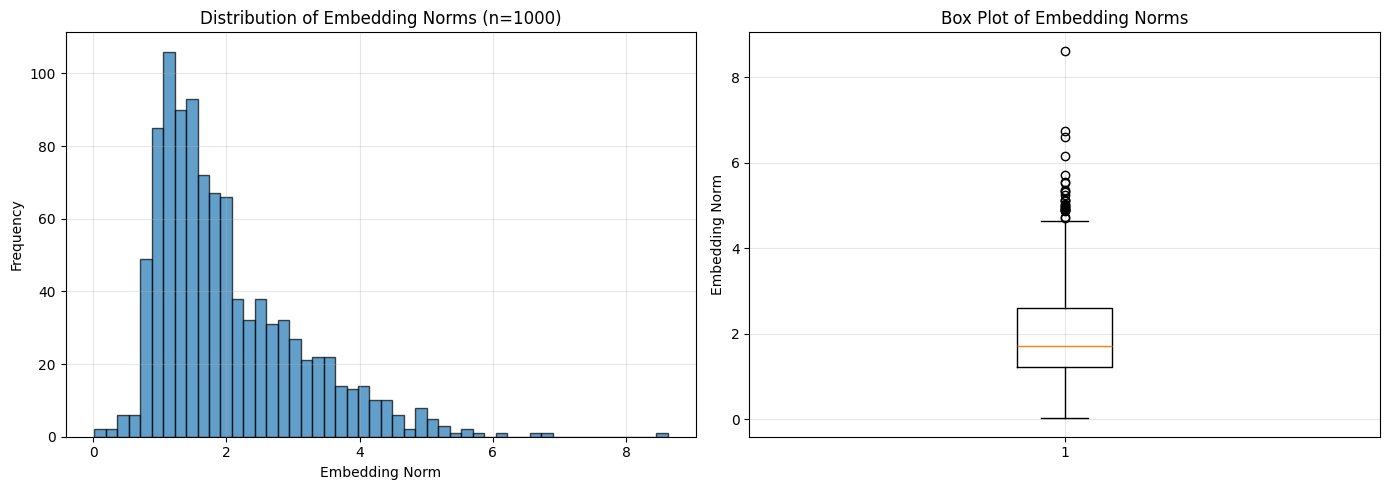


Statistics for 1000 word embeddings:
Mean norm: 2.0207
Std norm: 1.0847
Min norm: 0.0167
Max norm: 8.6235
Median norm: 1.7098


In [42]:
import matplotlib.pyplot as plt

# Sample n words and calculate embedding norms
n = 1000  # Number of words to sample

# Get vocabulary from word2vec model
vocab_words = list(word2vec_model.index_to_key)
print(f"Total vocabulary size: {len(vocab_words)}")

# Sample n random words
np.random.seed(42)
sampled_words = np.random.choice(vocab_words, size=min(n, len(vocab_words)), replace=False)

# Calculate norms for sampled words
norms = []
for word in sampled_words:
    # embedding = word2vec_model[word]
    norm = np.linalg.norm(get_word_embedding(word, model_str='word2vec'))
    norms.append(norm)

norms = np.array(norms)

# Plot the distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(norms, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Embedding Norm')
axes[0].set_ylabel('Frequency')
axes[0].set_title(f'Distribution of Embedding Norms (n={len(sampled_words)})')
axes[0].grid(True, alpha=0.3)

# Box plot
axes[1].boxplot(norms)
axes[1].set_ylabel('Embedding Norm')
axes[1].set_title('Box Plot of Embedding Norms')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print(f"\nStatistics for {len(sampled_words)} word embeddings:")
print(f"Mean norm: {np.mean(norms):.4f}")
print(f"Std norm: {np.std(norms):.4f}")
print(f"Min norm: {np.min(norms):.4f}")
print(f"Max norm: {np.max(norms):.4f}")
print(f"Median norm: {np.median(norms):.4f}")

GPT-2 vocabulary size: 50257


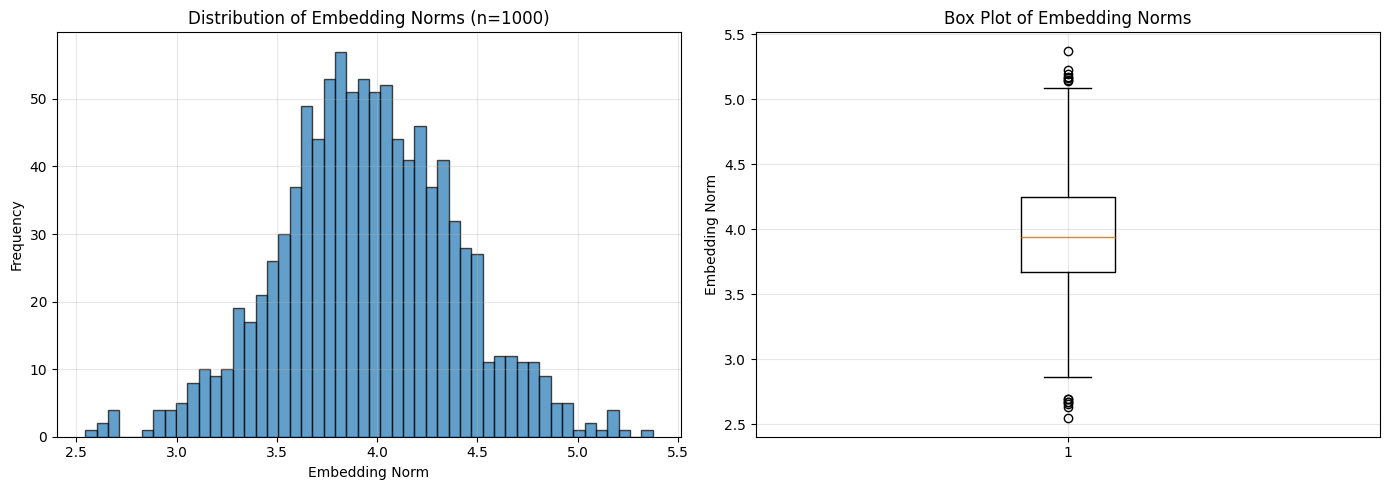


Statistics for 1000 token embeddings:
Mean norm: 3.9549
Std norm: 0.4371
Min norm: 2.5449
Max norm: 5.3749
Median norm: 3.9401


In [45]:
import matplotlib.pyplot as plt

# Sample n words and calculate embedding norms
n = 1000  # Number of words to sample

# Get vocabulary from word2vec model
vocab_size = len(tokenizer)
print(f"GPT-2 vocabulary size: {vocab_size}")

# Sample n random token IDs
np.random.seed(42)
sampled_token_ids = np.random.choice(vocab_size, size=min(n, vocab_size), replace=False)

# Calculate norms for sampled words
norms = []
for token_id in sampled_token_ids:
    # embedding = word2vec_model[word]
    norm = np.linalg.norm(get_word_embedding(tokenizer.decode(token_id), model_str='gpt2'))
    norms.append(norm)

norms = np.array(norms)

# Plot the distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(norms, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Embedding Norm')
axes[0].set_ylabel('Frequency')
axes[0].set_title(f'Distribution of Embedding Norms (n={len(sampled_token_ids)})')
axes[0].grid(True, alpha=0.3)

# Box plot
axes[1].boxplot(norms)
axes[1].set_ylabel('Embedding Norm')
axes[1].set_title('Box Plot of Embedding Norms')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print(f"\nStatistics for {len(sampled_token_ids)} token embeddings:")
print(f"Mean norm: {np.mean(norms):.4f}")
print(f"Std norm: {np.std(norms):.4f}")
print(f"Min norm: {np.min(norms):.4f}")
print(f"Max norm: {np.max(norms):.4f}")
print(f"Median norm: {np.median(norms):.4f}")

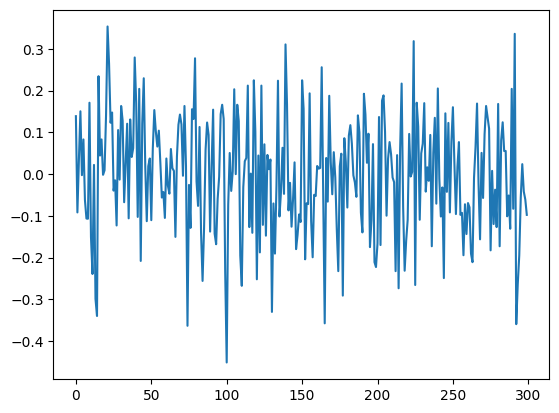

In [52]:
import matplotlib.pyplot as plt
plt.plot(get_word_embedding("me"))

In [64]:
import openai
from openai import OpenAI
import re

# Initialize OpenAI client
client = OpenAI()  # Will use OPENAI_API_KEY from environment

def generate_adjective_forms(base_adjective):
    """
    Generate comparative and superlative forms for an adjective.
    For simple cases, adds 'er' and 'est'.
    """
    # Simple rule-based approach
    if base_adjective.endswith('e'):
        comparative = base_adjective + 'r'
        superlative = base_adjective + 'st'
    elif base_adjective.endswith('y'):
        comparative = base_adjective[:-1] + 'ier'
        superlative = base_adjective[:-1] + 'iest'
    elif len(base_adjective) == 1:
        comparative = base_adjective + base_adjective + 'er'
        superlative = base_adjective + base_adjective + 'est'
    else:
        comparative = base_adjective + 'er'
        superlative = base_adjective + 'est'
    
    return comparative, superlative

def sample_adjectives_with_forms(
    target_count=200,
    verify_all_forms=True,
    verbose=True
):
    """
    Sample adjectives from word2vec vocab that have 'er' and 'est' forms as single tokens.
    
    Args:
        target_count (int): Target number of adjectives to sample (150-300 recommended)
        verify_all_forms (bool): 
            - If True: Only return adjectives where base, comparative, and superlative are all in vocab
            - If False: Return all adjectives without verification of forms
        verbose (bool): Print progress information
    
    Returns:
        dict: {
            'adjectives': list of base adjectives,
            'forms': {base: (comparative, superlative), ...},
            'count': number of valid adjectives found
        }
    """
    
    if verify_all_forms:
        current_vocab = set(word2vec_model.index_to_key)
    
    adjectives_to_test = []
    valid_adjectives = {}
    batch_size = 250  # Request adjectives in batches
    
    # Request adjectives from OpenAI in batches until we have enough
    while len(valid_adjectives) < target_count:
        remaining = target_count - len(valid_adjectives)
        request_count = min(batch_size, remaining*2)  # Request a bit more to account for filtering
        
        if verbose:
            print(f"Requesting {request_count} adjectives from OpenAI (current count: {len(valid_adjectives)})...")
        
        prompt = f"""Generate a list of exactly {request_count} common English adjectives that can have comparative ('er') and superlative ('est') forms.
        
Format: Return ONLY a comma-separated list with no explanations or numbering.
Example format: hot, cold, big, small, fast, slow, bright, dark

Requirements:
- Each adjective should be a single word
- They should be common adjectives
- They should typically form comparatives with 'er' and superlatives with 'est'
- Do NOT include adjectives that use 'more/most' for comparatives/superlatives

Notes:
- I want different adjectives from the ones you've already provided: {', '.join(valid_adjectives.keys())}
"""
        
        try:
            response = client.chat.completions.create(
                model="gpt-4o-mini",
                messages=[
                    {"role": "user", "content": prompt}
                ],
                temperature=0.6,
                max_tokens=500
            )
            
            # Parse the response
            adjective_text = response.choices[0].message.content.strip()
            batch_adjectives = [adj.strip().lower() for adj in adjective_text.split(',')]
            batch_adjectives = [adj for adj in batch_adjectives if adj and adj.isalpha()]
            
            if verbose:
                print(f"  Got {len(batch_adjectives)} adjectives from API")
            
            # Validate or collect adjectives
            for adj in batch_adjectives:
                if adj not in valid_adjectives:  # Avoid duplicates
                    if not verify_all_forms:
                        # Just add without verification
                        valid_adjectives[adj] = generate_adjective_forms(adj)
                    else:
                        # Verify all forms are in vocab
                        comparative, superlative = generate_adjective_forms(adj)
                        if adj in current_vocab and comparative in current_vocab and superlative in current_vocab:
                            valid_adjectives[adj] = (comparative, superlative)
                            if verbose and len(valid_adjectives) % 10 == 0:
                                print(f"  ✓ Found {len(valid_adjectives)} valid adjectives so far...")
        
        except Exception as e:
            print(f"Error calling OpenAI API: {e}")
            break
        
        # Stop if we haven't found enough after requesting a lot
        if len(adjectives_to_test) > target_count * 3:
            if verbose:
                print(f"Stopping: requested too many times without reaching target")
            break
    
    result = {
        'adjectives': list(valid_adjectives.keys()),
        'forms': valid_adjectives,
        'count': len(valid_adjectives),
        'verify_all_forms': verify_all_forms
    }
    
    if verbose:
        print(f"\n{'='*60}")
        print(f"Final Results:")
        print(f"  Target: {target_count}, Found: {len(valid_adjectives)}")
        print(f"  Verification: {'All forms validated in vocab' if verify_all_forms else 'No verification'}")
        print(f"{'='*60}\n")
        
        # Show some examples
        print("Examples:")
        for i, (base, (comp, sup)) in enumerate(list(valid_adjectives.items())[:10]):
            in_vocab = "✓" if verify_all_forms else "?"
            print(f"  {in_vocab} {base} → {comp} → {sup}")
        if len(valid_adjectives) > 10:
            print(f"  ... and {len(valid_adjectives) - 10} more")
    
    return result


# Example usage:
# 1. With verification (only adjectives where all 3 forms are in word2vec vocab)
result_verified = sample_adjectives_with_forms(target_count=80, verify_all_forms=True)

# 2. Without verification (just get adjectives from LLM)
# result_unverified = sample_adjectives_with_forms(target_count=200, verify_all_forms=False)

Requesting 160 adjectives from OpenAI (current count: 0)...
  Got 151 adjectives from API
  ✓ Found 10 valid adjectives so far...
  ✓ Found 20 valid adjectives so far...
  ✓ Found 30 valid adjectives so far...
  ✓ Found 40 valid adjectives so far...
  ✓ Found 50 valid adjectives so far...
  ✓ Found 60 valid adjectives so far...
  ✓ Found 70 valid adjectives so far...
  ✓ Found 80 valid adjectives so far...

Final Results:
  Target: 80, Found: 88
  Verification: All forms validated in vocab

Examples:
  ✓ tall → taller → tallest
  ✓ short → shorter → shortest
  ✓ long → longer → longest
  ✓ wide → wider → widest
  ✓ deep → deeper → deepest
  ✓ high → higher → highest
  ✓ fast → faster → fastest
  ✓ slow → slower → slowest
  ✓ rich → richer → richest
  ✓ poor → poorer → poorest
  ... and 78 more


In [65]:
result_verified

{'adjectives': ['tall',
  'short',
  'long',
  'wide',
  'deep',
  'high',
  'fast',
  'slow',
  'rich',
  'poor',
  'clean',
  'dirty',
  'light',
  'heavy',
  'hard',
  'soft',
  'bright',
  'dull',
  'sweet',
  'sour',
  'loud',
  'quiet',
  'warm',
  'cool',
  'clear',
  'dark',
  'sharp',
  'thick',
  'small',
  'old',
  'young',
  'kind',
  'cruel',
  'brave',
  'shy',
  'neat',
  'messy',
  'safe',
  'risky',
  'cheap',
  'simple',
  'friendly',
  'mean',
  'bitter',
  'tender',
  'rough',
  'smooth',
  'strong',
  'weak',
  'quick',
  'busy',
  'lazy',
  'smart',
  'dumb',
  'vague',
  'fresh',
  'stale',
  'early',
  'late',
  'happy',
  'angry',
  'calm',
  'nice',
  'pretty',
  'ugly',
  'funny',
  'healthy',
  'sick',
  'dry',
  'cold',
  'low',
  'blunt',
  'narrow',
  'full',
  'empty',
  'plain',
  'fancy',
  'easy',
  'clever',
  'gentle',
  'harsh',
  'close',
  'tight',
  'loose',
  'muddy',
  'rude',
  'polite',
  'dead'],
 'forms': {'tall': ('taller', 'tallest'),
  

In [136]:
from transformer_lens import HookedTransformer
import torch

def extract_residual_streams_for_adjectives(adjectives_dict, model_name="gpt2-small"):
    """
    Extract residual stream vectors from GPT-2 small for comparative and superlative forms.
    
    Args:
        adjectives_dict (dict): Dictionary with format {base: (comparative, superlative), ...}
                               (e.g., from the sample_adjectives_with_forms output)
        model_name (str): Name of the model to use (default: "gpt2-small")
    
    Returns:
        dict: {
            'base_adjective': str,
            'forms': {'comparative': str, 'superlative': str},
            'tokens': {
                'comparative': list of tokens,
                'superlative': list of tokens
            },
            'residual_streams': {
                'comparative': {
                    'layer_0': tensor [seq_len, hidden_dim],
                    'layer_1': tensor [seq_len, hidden_dim],
                    ...
                },
                'superlative': {
                    'layer_0': tensor [seq_len, hidden_dim],
                    ...
                }
            }
        }
    """
    
    # Load model
    print(f"Loading {model_name}...")
    model = HookedTransformer.from_pretrained(model_name)
    n_layers = model.cfg.n_layers
    print(f"Model loaded. Number of layers: {n_layers}")
    
    all_results = []
    
    for base_adj, (comparative, superlative) in adjectives_dict.items():
        print(f"\nProcessing: {base_adj} → {comparative}, {superlative}")
        
        result = {
            'base_adjective': base_adj,
            'forms': {'comparative': comparative, 'superlative': superlative},
            'tokens': {},
            'residual_streams': {}
        }
        
        # Process comparative and superlative forms
        for form_type, word in [('base', base_adj),('comparative', comparative), ('superlative', superlative)]:
            
            # Tokenize
            tokens = model.to_tokens(word, prepend_bos=True)  # [1, seq_len]
            tokens_list = tokens[0].tolist()
            result['tokens'][form_type] = tokens_list
            
            # Dictionary to store residual streams for each layer
            residuals_by_layer = {}
            
            # Hook function to capture residual streams
            def capture_residual(residual, hook):
                # residual shape: [batch, seq_len, hidden_dim]
                residuals_by_layer[hook.name] = residual.detach().cpu()
            
            # Register hooks for residual streams after each layer
            hook_names = [f"blocks.{i}.hook_resid_post" for i in range(n_layers)]
            
            # with model.hooks.manage_hooks():
            for hook_name in hook_names:
                model.add_hook(hook_name, capture_residual)
            
            # Forward pass
            with torch.no_grad():
                _ = model(tokens)
            
            # Organize residuals by layer
            result['residual_streams'][form_type] = {}
            for i in range(n_layers):
                hook_name = f"blocks.{i}.hook_resid_post"
                if hook_name in residuals_by_layer:
                    # Shape: [1, seq_len, hidden_dim] -> remove batch dim -> [seq_len, hidden_dim]
                    result['residual_streams'][form_type][f'layer_{i}'] = residuals_by_layer[hook_name][0]
        
        all_results.append(result)
    
    print(f"\n{'='*60}")
    print(f"Extraction complete!")
    print(f"Processed {len(all_results)} adjectives")
    print(f"{'='*60}")
    
    return all_results


# Example usage:
residuals = extract_residual_streams_for_adjectives(result_verified['forms'])
# 
# # Access specific residual vector
# residual_vector = get_residual_at_position(
#     residuals, 
#     base_adj='hot', 
#     form_type='comparative',
#     layer=5,
#     position=1
# )
# print(residual_vector.shape)  # Should be [768] for gpt2-small

Loading gpt2-small...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded pretrained model gpt2-small into HookedTransformer
Model loaded. Number of layers: 12

Processing: tall → taller, tallest

Processing: short → shorter, shortest

Processing: long → longer, longest

Processing: wide → wider, widest

Processing: deep → deeper, deepest

Processing: high → higher, highest

Processing: fast → faster, fastest

Processing: slow → slower, slowest

Processing: rich → richer, richest

Processing: poor → poorer, poorest

Processing: clean → cleaner, cleanest

Processing: dirty → dirtier, dirtiest

Processing: light → lighter, lightest

Processing: heavy → heavier, heaviest

Processing: hard → harder, hardest

Processing: soft → softer, softest

Processing: bright → brighter, brightest

Processing: dull → duller, dullest

Processing: sweet → sweeter, sweetest

Processing: sour → sourer, sourest

Processing: loud → louder, loudest

Processing: quiet → quieter, quietest

Processing: warm → warmer, warmest

Processing: cool → cooler, coolest

Processing: clear

In [137]:
residuals_dict = {val['base_adjective']:{k:v for k,v in val.items() if k != 'base_adjective'} for val in residuals}
del residuals

In [107]:
residuals_dict['tall']['residual_streams'].keys()

dict_keys(['base', 'comparative', 'superlative'])

In [162]:

def calculate_difference(residual_data, form_types_tuple):
    """
    Helper function to calculate difference vector between the hidden states of last position between the specified form_types.
    It returns a dict.
    Key :- adjective
    value:- Dict[layer_number: tensor of difference vectors with all the layers]
    
    Args:
        residual_data (dict): Dictionary with adjectives as keys and residual data as values
        form_types_tuple (tuple): Tuple of two form types, e.g., ('comparative', 'superlative')
    
    Returns:
        dict: {adjective: {layer_name: difference_tensor, ...}, ...}
    """
    
    result = {}
    form_type_1, form_type_2 = form_types_tuple
    
    for adjective, adj_data in residual_data.items():
        residual_streams = adj_data['residual_streams']
        
        # Check if both form types exist
        if form_type_1 not in residual_streams or form_type_2 not in residual_streams:
            print(f"Warning: Missing form types for adjective '{adjective}'")
            continue
        
        layer_differences = {}
        form1_layers = residual_streams[form_type_1]
        form2_layers = residual_streams[form_type_2]
        
        # Calculate difference for each layer
        for layer_name in form1_layers.keys():
            form1_last = form1_layers[layer_name][-1]  # Last position
            difference = torch.empty(0, form1_last.size(-1))  # Default to zero if form2 layer is missing
            
            for layer_name2 in form2_layers.keys():                                                                    
                form2_last = form2_layers[layer_name2][-1]  # Last position           
                # Calculate difference
                difference = torch.vstack((difference, form2_last - form1_last))
                
            layer_differences[layer_name] = difference
        
        result[adjective] = layer_differences
    
    return result

results = {}
results['base_vs_comparative'] = calculate_difference(residuals_dict, ('base', 'comparative'))


In [168]:
calculate_difference(residuals_dict, ('base', 'comparative'))['tall']['layer_0'] + calculate_difference(residuals_dict, ('comparative','base'))['tall']['layer_0'].T

RuntimeError: The size of tensor a (768) must match the size of tensor b (12) at non-singleton dimension 1

In [173]:
diff = torch.empty(0,768)
for l in range(12):
    diff = torch.cat([diff, calculate_difference(residuals_dict, ('comparative','base'))['tall'][f'layer_{l}'][0,:].unsqueeze(0)], dim=0)
calculate_difference(residuals_dict, ('base', 'comparative'))['tall']['layer_0'] + diff

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

In [165]:
results['comparative_vs_superlative'] = calculate_difference(residuals_dict, ('comparative', 'superlative'))
results['base_vs_superlative'] = calculate_difference(residuals_dict, ('base', 'superlative'))

In [140]:
def compute_layer_alignment_matrix(results_dict, form_comparison_key='base_vs_comparative', n_layers=12):
    """
    Compute a 12x12 matrix of average dot products between layer difference vectors across adjectives.
    
    For each pair of layers (i, j), computes the average dot product between difference vectors
    across all pairs of adjectives. This measures how aligned the comparative/superlative directions
    are at different layers.
    
    Args:
        results_dict (dict): Dictionary with structure results_dict[comparison_key][adjective][f'layer_{i}']
                            where each value is a tensor of shape (12, 768)
        form_comparison_key (str): Key in results_dict to use (e.g., 'base_vs_comparative')
        n_layers (int): Number of layers in the model (default: 12 for GPT-2 small)
    
    Returns:
        tuple: (alignment_matrix, adjective_pairs_count)
            - alignment_matrix: 12x12 torch tensor where M[i,j] = average dot product between layer_i and layer_j
            - adjective_pairs_count: number of adjective pairs used in averaging
    """
    
    comparison_results = results_dict[form_comparison_key]
    
    # Initialize matrix to store sum of dot products
    dot_product_matrix = torch.zeros((n_layers, n_layers))
    adjective_pairs_count = 0
    
    adjectives = list(comparison_results.keys())
    n_adj = len(adjectives)
    
    print(f"Computing alignment matrix for {n_adj} adjectives...")
    print(f"Processing {n_adj * (n_adj - 1) // 2} adjective pairs...")
    
    # For each pair of adjectives
    for idx1 in range(n_adj):
        if (idx1 + 1) % 5 == 0:
            print(f"  Processing adjective pair {idx1}/{n_adj}...")
        
        adj1 = adjectives[idx1]
        
        for idx2 in range(idx1 + 1, n_adj):
            adj2 = adjectives[idx2]
            
            # For each pair of layers (i, j)
            for i in range(n_layers):
                for j in range(n_layers):
                    layer_key_i = f'layer_{i}'
                    
                    # Get difference vectors at layer i, position j
                    # diff_vectors[j] = comparative_layer_j_residual - base_layer_i_residual
                    try:
                        diff_adj1_ij = comparison_results[adj1][layer_key_i][j]  # 768 dim
                        diff_adj2_ij = comparison_results[adj2][layer_key_i][j]  # 768 dim
                        
                        # Compute dot product between the two difference vectors
                        dot_prod = torch.nn.functional.cosine_similarity(diff_adj1_ij.unsqueeze(0), diff_adj2_ij.unsqueeze(0)).item()
                        
                        # Add to matrix
                        dot_product_matrix[i, j] += dot_prod
                    
                    except IndexError:
                        continue
            
            adjective_pairs_count += 1
    
    # Average over all adjective pairs
    if adjective_pairs_count > 0:
        dot_product_matrix /= adjective_pairs_count
    
    print(f"✓ Computed alignment matrix using {adjective_pairs_count} adjective pairs")
    return dot_product_matrix, adjective_pairs_count


# Compute the alignment matrix
alignment_matrix, n_pairs = compute_layer_alignment_matrix(results)

print(f"\nAlignment Matrix Shape: {alignment_matrix.shape}")
print(f"Number of adjective pairs used: {n_pairs}")
print(f"\nMatrix Statistics:")
print(f"  Min value: {alignment_matrix.min():.4f}")
print(f"  Max value: {alignment_matrix.max():.4f}")
print(f"  Mean value: {alignment_matrix.mean():.4f}")
print(f"  Mean (upper triangle): {alignment_matrix.triu(1).mean():.4f}")


Computing alignment matrix for 88 adjectives...
Processing 3828 adjective pairs...
  Processing adjective pair 4/88...
  Processing adjective pair 9/88...
  Processing adjective pair 14/88...
  Processing adjective pair 19/88...
  Processing adjective pair 24/88...
  Processing adjective pair 29/88...
  Processing adjective pair 34/88...
  Processing adjective pair 39/88...
  Processing adjective pair 44/88...
  Processing adjective pair 49/88...
  Processing adjective pair 54/88...
  Processing adjective pair 59/88...
  Processing adjective pair 64/88...
  Processing adjective pair 69/88...
  Processing adjective pair 74/88...
  Processing adjective pair 79/88...
  Processing adjective pair 84/88...
✓ Computed alignment matrix using 3828 adjective pairs

Alignment Matrix Shape: torch.Size([12, 12])
Number of adjective pairs used: 3828

Matrix Statistics:
  Min value: 0.1487
  Max value: 0.9542
  Mean value: 0.5584
  Mean (upper triangle): 0.2749


In [146]:
def compute_cross_comparison_alignment_matrix(results_dict, form_comparison_1='base_vs_comparative', form_comparison_2='comparative_vs_superlative', n_layers=12):
    """
    Compute 12x12 matrix of cosine similarities between difference vectors from two different form comparisons.
    
    For each layer pair (i,j), computes the average cosine similarity between:
    - Difference vectors from form_comparison_1 at layer i, position j
    - Difference vectors from form_comparison_2 at layer i, position j
    
    Averaged across all adjectives.
    
    Args:
        results_dict (dict): Dictionary with keys like 'base_vs_comparative', 'comparative_vs_superlative'
                            each containing adjective -> layer_i -> [12, 768] tensors
        form_comparison_1 (str): First form comparison key (default: 'base_vs_comparative')
        form_comparison_2 (str): Second form comparison key (default: 'comparative_vs_superlative')
        n_layers (int): Number of layers (default: 12 for GPT-2 small)
    
    Returns:
        tuple: (alignment_matrix, adjective_count)
            - alignment_matrix: 12x12 torch tensor where M[i,j] = average cosine similarity
              between difference vectors at base layer i and position j across both comparisons
            - adjective_count: number of adjectives used in averaging
    """
    
    comp1_results = results_dict[form_comparison_1]
    comp2_results = results_dict[form_comparison_2]
    
    # Initialize matrix
    similarity_matrix = torch.zeros((n_layers, n_layers))
    adjective_count = 0
    
    adjectives = list(comp1_results.keys())
    n_adj = len(adjectives)
    
    print(f"Computing cross-comparison alignment matrix...")
    print(f"  Comparison 1: {form_comparison_1}")
    print(f"  Comparison 2: {form_comparison_2}")
    print(f"  Number of adjectives: {n_adj}")
    
    # For each adjective
    for adj_idx, adj in enumerate(adjectives):
        if (adj_idx + 1) % 10 == 0:
            print(f"  Processing adjective {adj_idx + 1}/{n_adj}...")
        
        # For each base layer i
        for i in range(n_layers):
            layer_key = f'layer_{i}'
            
            try:
                # Get difference vectors for this layer from both comparisons
                diff_vec_1 = comp1_results[adj][layer_key]  # shape: [12, 768]
                diff_vec_2 = comp2_results[adj][layer_key]  # shape: [12, 768]
                
                # For each comparative/superlative layer j
                for j in range(n_layers):
                    # Get the j-th difference vector from each comparison
                    vec_1 = diff_vec_1[j]  # shape: [768]
                    vec_2 = diff_vec_2[j]  # shape: [768]
                    
                    # Compute cosine similarity
                    cosine_sim = torch.nn.functional.cosine_similarity(
                        vec_1.unsqueeze(0), 
                        vec_2.unsqueeze(0)
                    ).item()
                    
                    similarity_matrix[i, j] += cosine_sim
            
            except (KeyError, IndexError) as e:
                print(f"Warning: Could not process adjective '{adj}' at layer {i}")
                continue
        
        adjective_count += 1
    
    # Average over adjectives
    if adjective_count > 0:
        similarity_matrix /= adjective_count
    
    print(f"✓ Computed cross-comparison alignment matrix using {adjective_count} adjectives")
    return similarity_matrix, adjective_count



In [141]:
# Visualize the upper triangular alignment matrix with Plotly
import plotly.graph_objects as go

# Extract upper triangular matrix
upper_matrix = alignment_matrix.triu(1).numpy()
upper_matrix[upper_matrix == 0] = np.nan  # Set lower triangle to NaN for better visualization
# Create the interactive heatmap
fig = go.Figure(data=go.Heatmap(
    z=upper_matrix,
    x=list(range(12)),
    y=list(range(12)),
    colorscale='Viridis',
    hovertemplate='Base Layer: %{y}<br>Comparative Layer: %{x}<br>Alignment Score: %{z:.4f}<extra></extra>',
    colorbar=dict(title='Average Dot Product')
))

fig.update_layout(
    title={
        'text': 'Layer Alignment Matrix (Upper Triangular)<br><sub>Average cosine similarity of difference vectors across adjectives</sub>',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 14}
    },
    xaxis_title='Comparative Form Layers (j)',
    yaxis_title='Base Form Layers (i)',
    width=900,
    height=800,
    hovermode='closest',
    xaxis={'tickmode': 'linear', 'tick0': 0, 'dtick': 1},
    yaxis={'tickmode': 'linear', 'tick0': 0, 'dtick': 1, 'autorange': 'reversed'},
)

fig.show()

print(f"\nInterpretation:")
print(f"- M[i,j] = average alignment between base_layer_i and comparative_layer_j directions")
print(f"- Upper triangular (j > i) shows forward layer flow")
print(f"- Hover over cells for exact alignment scores")
print(f"- Brighter colors = higher alignment between layers")


Interpretation:
- M[i,j] = average alignment between base_layer_i and comparative_layer_j directions
- Upper triangular (j > i) shows forward layer flow
- Hover over cells for exact alignment scores
- Brighter colors = higher alignment between layers


In [142]:
# Compute the alignment matrix
alignment_matrix, n_pairs = compute_layer_alignment_matrix(results, form_comparison_key='comparative_vs_superlative')

Computing alignment matrix for 88 adjectives...
Processing 3828 adjective pairs...
  Processing adjective pair 4/88...
  Processing adjective pair 9/88...
  Processing adjective pair 14/88...
  Processing adjective pair 19/88...
  Processing adjective pair 24/88...
  Processing adjective pair 29/88...
  Processing adjective pair 34/88...
  Processing adjective pair 39/88...
  Processing adjective pair 44/88...
  Processing adjective pair 49/88...
  Processing adjective pair 54/88...
  Processing adjective pair 59/88...
  Processing adjective pair 64/88...
  Processing adjective pair 69/88...
  Processing adjective pair 74/88...
  Processing adjective pair 79/88...
  Processing adjective pair 84/88...
✓ Computed alignment matrix using 3828 adjective pairs


In [143]:
# Visualize the upper triangular alignment matrix with Plotly
import plotly.graph_objects as go

# Extract upper triangular matrix
upper_matrix = alignment_matrix.triu(1).numpy()
upper_matrix[upper_matrix == 0] = np.nan  # Set lower triangle to NaN for better visualization
# Create the interactive heatmap
fig = go.Figure(data=go.Heatmap(
    z=upper_matrix,
    x=list(range(12)),
    y=list(range(12)),
    colorscale='Viridis',
    hovertemplate='Base Layer: %{y}<br>Comparative Layer: %{x}<br>Alignment Score: %{z:.4f}<extra></extra>',
    colorbar=dict(title='Average Dot Product')
))

fig.update_layout(
    title={
        'text': 'Layer Alignment Matrix (Upper Triangular)<br><sub>Average cosine similarity of difference vectors across adjectives</sub>',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 14}
    },
    xaxis_title='Comparative Form Layers (j)',
    yaxis_title='Base Form Layers (i)',
    width=900,
    height=800,
    hovermode='closest',
    xaxis={'tickmode': 'linear', 'tick0': 0, 'dtick': 1},
    yaxis={'tickmode': 'linear', 'tick0': 0, 'dtick': 1, 'autorange': 'reversed'},
)

fig.show()

print(f"\nInterpretation:")
print(f"- M[i,j] = average alignment between base_layer_i and comparative_layer_j directions")
print(f"- Upper triangular (j > i) shows forward layer flow")
print(f"- Hover over cells for exact alignment scores")
print(f"- Brighter colors = higher alignment between layers")


Interpretation:
- M[i,j] = average alignment between base_layer_i and comparative_layer_j directions
- Upper triangular (j > i) shows forward layer flow
- Hover over cells for exact alignment scores
- Brighter colors = higher alignment between layers


In [144]:
# Compute the alignment matrix
alignment_matrix, n_pairs = compute_layer_alignment_matrix(results, form_comparison_key='base_vs_superlative')

Computing alignment matrix for 88 adjectives...
Processing 3828 adjective pairs...
  Processing adjective pair 4/88...
  Processing adjective pair 9/88...
  Processing adjective pair 14/88...
  Processing adjective pair 19/88...
  Processing adjective pair 24/88...
  Processing adjective pair 29/88...
  Processing adjective pair 34/88...
  Processing adjective pair 39/88...
  Processing adjective pair 44/88...
  Processing adjective pair 49/88...
  Processing adjective pair 54/88...
  Processing adjective pair 59/88...
  Processing adjective pair 64/88...
  Processing adjective pair 69/88...
  Processing adjective pair 74/88...
  Processing adjective pair 79/88...
  Processing adjective pair 84/88...
✓ Computed alignment matrix using 3828 adjective pairs


In [145]:
# Visualize the upper triangular alignment matrix with Plotly
import plotly.graph_objects as go

# Extract upper triangular matrix
upper_matrix = alignment_matrix.triu(1).numpy()
upper_matrix[upper_matrix == 0] = np.nan  # Set lower triangle to NaN for better visualization
# Create the interactive heatmap
fig = go.Figure(data=go.Heatmap(
    z=upper_matrix,
    x=list(range(12)),
    y=list(range(12)),
    colorscale='Viridis',
    hovertemplate='Base Layer: %{y}<br>Comparative Layer: %{x}<br>Alignment Score: %{z:.4f}<extra></extra>',
    colorbar=dict(title='Average Dot Product')
))

fig.update_layout(
    title={
        'text': 'Layer Alignment Matrix (Upper Triangular)<br><sub>Average cosine similarity of difference vectors across adjectives</sub>',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 14}
    },
    xaxis_title='Comparative Form Layers (j)',
    yaxis_title='Base Form Layers (i)',
    width=900,
    height=800,
    hovermode='closest',
    xaxis={'tickmode': 'linear', 'tick0': 0, 'dtick': 1},
    yaxis={'tickmode': 'linear', 'tick0': 0, 'dtick': 1, 'autorange': 'reversed'},
)

fig.show()

print(f"\nInterpretation:")
print(f"- M[i,j] = average alignment between base_layer_i and comparative_layer_j directions")
print(f"- Upper triangular (j > i) shows forward layer flow")
print(f"- Hover over cells for exact alignment scores")
print(f"- Brighter colors = higher alignment between layers")


Interpretation:
- M[i,j] = average alignment between base_layer_i and comparative_layer_j directions
- Upper triangular (j > i) shows forward layer flow
- Hover over cells for exact alignment scores
- Brighter colors = higher alignment between layers


In [147]:
# Example usage: Compare base_vs_comparative with comparative_vs_superlative
cross_comparison_matrix, n_adj = compute_cross_comparison_alignment_matrix(
    results, 
    form_comparison_1='base_vs_comparative',
    form_comparison_2='comparative_vs_superlative'
)

print(f"\nCross-Comparison Alignment Matrix Shape: {cross_comparison_matrix.shape}")
print(f"Number of adjectives: {n_adj}")
print(f"\nMatrix Statistics:")
print(f"  Min value: {cross_comparison_matrix.min():.4f}")
print(f"  Max value: {cross_comparison_matrix.max():.4f}")
print(f"  Mean value: {cross_comparison_matrix.mean():.4f}")


Computing cross-comparison alignment matrix...
  Comparison 1: base_vs_comparative
  Comparison 2: comparative_vs_superlative
  Number of adjectives: 88
  Processing adjective 10/88...
  Processing adjective 20/88...
  Processing adjective 30/88...
  Processing adjective 40/88...
  Processing adjective 50/88...
  Processing adjective 60/88...
  Processing adjective 70/88...
  Processing adjective 80/88...
✓ Computed cross-comparison alignment matrix using 88 adjectives

Cross-Comparison Alignment Matrix Shape: torch.Size([12, 12])
Number of adjectives: 88

Matrix Statistics:
  Min value: -0.4266
  Max value: 0.9449
  Mean value: 0.3156


In [148]:
# Visualize the cross-comparison alignment matrix with Plotly
import plotly.graph_objects as go

# Extract upper triangular matrix
upper_matrix = cross_comparison_matrix.triu(1).numpy()
upper_matrix[upper_matrix == 0] = np.nan  # Set lower triangle to NaN for better visualization

# Create the interactive heatmap
fig = go.Figure(data=go.Heatmap(
    z=upper_matrix,
    x=list(range(12)),
    y=list(range(12)),
    colorscale='Viridis',
    hovertemplate='Base Layer: %{y}<br>Form2 Layer: %{x}<br>Cosine Similarity: %{z:.4f}<extra></extra>',
    colorbar=dict(title='Cosine Similarity')
))

fig.update_layout(
    title={
        'text': 'Cross-Comparison Alignment Matrix (Upper Triangular)<br><sub>Cosine similarity between base_vs_comparative and comparative_vs_superlative difference vectors</sub>',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 14}
    },
    xaxis_title='Form2 Layers (j)',
    yaxis_title='Base Layers (i)',
    width=900,
    height=800,
    hovermode='closest',
    xaxis={'tickmode': 'linear', 'tick0': 0, 'dtick': 1},
    yaxis={'tickmode': 'linear', 'tick0': 0, 'dtick': 1, 'autorange': 'reversed'},
)

fig.show()

print(f"\nInterpretation:")
print(f"- M[i,j] = average cosine similarity between difference vectors at base layer i, position j")
print(f"- Compares: base→comp direction vs comparative→superlative direction")
print(f"- Upper triangular (j > i) shows forward layer flow")
print(f"- Hover over cells for exact similarity scores")
print(f"- Values closer to 1.0 = directions are aligned across both comparisons")



Interpretation:
- M[i,j] = average cosine similarity between difference vectors at base layer i, position j
- Compares: base→comp direction vs comparative→superlative direction
- Upper triangular (j > i) shows forward layer flow
- Hover over cells for exact similarity scores
- Values closer to 1.0 = directions are aligned across both comparisons


In [151]:
results['superlative_vs_comparative'] = calculate_difference(residuals_dict, ('superlative', 'comparative'))

In [175]:
results['superlative_vs_comparative']['tall']['layer_2'] + results['comparative_vs_superlative']['tall']['layer_2']

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

In [174]:
results_dict = {}
for adj in results['comparative_vs_superlative'].keys():
    results_dict[adj] = {}
    difference_dict = calculate_difference(residuals_dict, ('superlative','comparative'))[adj]
    for layer1 in range(12):
        diff = torch.empty(0,768)
        for l in range(12):
            diff = torch.cat([diff, difference_dict[f'layer_{l}'][layer1,:].unsqueeze(0)], dim=0)
        results_dict[adj][f"layer_{layer1}"] = diff
results['superlative_vs_comparative'] = results_dict

In [176]:
# Example usage: Compare base_vs_comparative with comparative_vs_superlative
cross_comparison_matrix, n_adj = compute_cross_comparison_alignment_matrix(
    results, 
    form_comparison_1='base_vs_comparative',
    form_comparison_2='superlative_vs_comparative'
)

print(f"\nCross-Comparison Alignment Matrix Shape: {cross_comparison_matrix.shape}")
print(f"Number of adjectives: {n_adj}")
print(f"\nMatrix Statistics:")
print(f"  Min value: {cross_comparison_matrix.min():.4f}")
print(f"  Max value: {cross_comparison_matrix.max():.4f}")
print(f"  Mean value: {cross_comparison_matrix.mean():.4f}")


Computing cross-comparison alignment matrix...
  Comparison 1: base_vs_comparative
  Comparison 2: superlative_vs_comparative
  Number of adjectives: 88
  Processing adjective 10/88...
  Processing adjective 20/88...
  Processing adjective 30/88...
  Processing adjective 40/88...
  Processing adjective 50/88...
  Processing adjective 60/88...
  Processing adjective 70/88...
  Processing adjective 80/88...
✓ Computed cross-comparison alignment matrix using 88 adjectives

Cross-Comparison Alignment Matrix Shape: torch.Size([12, 12])
Number of adjectives: 88

Matrix Statistics:
  Min value: -0.9449
  Max value: 0.4266
  Mean value: -0.3156


In [177]:
# Visualize the cross-comparison alignment matrix with Plotly
import plotly.graph_objects as go

# Extract upper triangular matrix
upper_matrix = cross_comparison_matrix.triu(1).numpy()
upper_matrix[upper_matrix == 0] = np.nan  # Set lower triangle to NaN for better visualization

# Create the interactive heatmap
fig = go.Figure(data=go.Heatmap(
    z=upper_matrix,
    x=list(range(12)),
    y=list(range(12)),
    colorscale='Viridis',
    hovertemplate='Base Layer: %{y}<br>Form2 Layer: %{x}<br>Cosine Similarity: %{z:.4f}<extra></extra>',
    colorbar=dict(title='Cosine Similarity')
))

fig.update_layout(
    title={
        'text': 'Cross-Comparison Alignment Matrix (Upper Triangular)<br><sub>Cosine similarity between base_vs_comparative and comparative_vs_superlative difference vectors</sub>',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 14}
    },
    xaxis_title='Form2 Layers (j)',
    yaxis_title='Base Layers (i)',
    width=900,
    height=800,
    hovermode='closest',
    xaxis={'tickmode': 'linear', 'tick0': 0, 'dtick': 1},
    yaxis={'tickmode': 'linear', 'tick0': 0, 'dtick': 1, 'autorange': 'reversed'},
)

fig.show()

print(f"\nInterpretation:")
print(f"- M[i,j] = average cosine similarity between difference vectors at base layer i, position j")
print(f"- Compares: base→comp direction vs comparative→superlative direction")
print(f"- Upper triangular (j > i) shows forward layer flow")
print(f"- Hover over cells for exact similarity scores")
print(f"- Values closer to 1.0 = directions are aligned across both comparisons")



Interpretation:
- M[i,j] = average cosine similarity between difference vectors at base layer i, position j
- Compares: base→comp direction vs comparative→superlative direction
- Upper triangular (j > i) shows forward layer flow
- Hover over cells for exact similarity scores
- Values closer to 1.0 = directions are aligned across both comparisons


In [124]:
# Detailed analysis of the alignment matrix
print("="*70)
print("ALIGNMENT MATRIX ANALYSIS")
print("="*70)

# Diagonal analysis
print("\n1. DIAGONAL ANALYSIS (layer i vs layer i):")
print("   (How aligned are the difference directions at the same layer?)")
diag_values = torch.diagonal(alignment_matrix).numpy()
for i, val in enumerate(diag_values):
    print(f"   Layer {i:2d}: {val:8.4f}")

# Upper triangle statistics
upper_triangle = alignment_matrix.triu(1)
upper_nonzero = upper_triangle[upper_triangle != 0]
print(f"\n2. UPPER TRIANGLE STATISTICS (layers i < j):")
print(f"   Mean: {upper_nonzero.mean():.4f}")
print(f"   Std:  {upper_nonzero.std():.4f}")
print(f"   Min:  {upper_nonzero.min():.4f}")
print(f"   Max:  {upper_nonzero.max():.4f}")

# Lower triangle statistics
lower_triangle = alignment_matrix.tril(-1)
lower_nonzero = lower_triangle[lower_triangle != 0]
if len(lower_nonzero) > 0:
    print(f"\n3. LOWER TRIANGLE STATISTICS (layers i > j):")
    print(f"   Mean: {lower_nonzero.mean():.4f}")
    print(f"   Std:  {lower_nonzero.std():.4f}")
    print(f"   Min:  {lower_nonzero.min():.4f}")
    print(f"   Max:  {lower_nonzero.max():.4f}")
    print(f"   (Should ideally be close to zero)")

# Row and column averages
row_means = alignment_matrix.mean(dim=1)
col_means = alignment_matrix.mean(dim=0)

print(f"\n4. ROW AVERAGES (average alignment FROM each base layer):")
for i, val in enumerate(row_means):
    print(f"   Layer {i:2d}: {val:.4f}")

print(f"\n5. COLUMN AVERAGES (average alignment TO each comparative layer):")
for j, val in enumerate(col_means):
    print(f"   Layer {j:2d}: {val:.4f}")


ALIGNMENT MATRIX ANALYSIS

1. DIAGONAL ANALYSIS (layer i vs layer i):
   (How aligned are the difference directions at the same layer?)
   Layer  0:   0.3472
   Layer  1:   0.3315
   Layer  2:   0.3211
   Layer  3:   0.2866
   Layer  4:   0.3218
   Layer  5:   0.3327
   Layer  6:   0.3251
   Layer  7:   0.3135
   Layer  8:   0.3232
   Layer  9:   0.3348
   Layer 10:   0.3174
   Layer 11:   0.3972

2. UPPER TRIANGLE STATISTICS (layers i < j):
   Mean: 0.3477
   Std:  0.1545
   Min:  0.1637
   Max:  0.8752

3. LOWER TRIANGLE STATISTICS (layers i > j):
   Mean: 0.5653
   Std:  0.1166
   Min:  0.3218
   Max:  0.7236
   (Should ideally be close to zero)

4. ROW AVERAGES (average alignment FROM each base layer):
   Layer  0: 0.5216
   Layer  1: 0.4338
   Layer  2: 0.2617
   Layer  3: 0.2610
   Layer  4: 0.3420
   Layer  5: 0.4041
   Layer  6: 0.4409
   Layer  7: 0.4896
   Layer  8: 0.5298
   Layer  9: 0.5673
   Layer 10: 0.6274
   Layer 11: 0.4719

5. COLUMN AVERAGES (average alignment TO ea

In [167]:
# Debug: Check what's in the results dict and compare values
print("="*70)
print("DEBUG: Checking results dictionary structure")
print("="*70)

# Pick first adjective
first_adj = list(results['base_vs_comparative'].keys())[0]
print(f"\nFirst adjective: {first_adj}")

# Check layer_0 structure
layer_0_bc = results['base_vs_comparative'][first_adj]['layer_0']
layer_0_cs = results['comparative_vs_superlative'][first_adj]['layer_0']

print(f"\nbase_vs_comparative[layer_0] shape: {layer_0_bc.shape}")
print(f"comparative_vs_superlative[layer_0] shape: {layer_0_cs.shape}")

# Check a specific vector
print(f"\nbase_vs_comparative[layer_0][0] (first vector):")
print(f"  Shape: {layer_0_bc[0].shape}")
print(f"  Norm: {torch.norm(layer_0_bc[0]):.6f}")
print(f"  Mean: {layer_0_bc[0].mean():.6f}")

print(f"\ncomparative_vs_superlative[layer_0][0] (first vector):")
print(f"  Shape: {layer_0_cs[0].shape}")
print(f"  Norm: {torch.norm(layer_0_cs[0]):.6f}")
print(f"  Mean: {layer_0_cs[0].mean():.6f}")

n_layers = 12
# Check cosine similarity for a few samples
print(f"\nCosine similarities for layer_0:")
for j in range(min(3, n_layers)):
    sim = torch.nn.functional.cosine_similarity(
        layer_0_bc[j].unsqueeze(0), 
        layer_0_cs[j].unsqueeze(0)
    ).item()
    print(f"  Position {j}: {sim:.6f}")

# Print the cross_comparison_matrix
print(f"\n" + "="*70)
print(f"Cross-comparison matrix (full):")
print(f"="*70)
print(cross_comparison_matrix)
print(f"\nMatrix stats:")
print(f"  Shape: {cross_comparison_matrix.shape}")
print(f"  Min: {cross_comparison_matrix.min():.6f}")
print(f"  Max: {cross_comparison_matrix.max():.6f}")
print(f"  Mean: {cross_comparison_matrix.mean():.6f}")
print(f"  Num zeros: {(cross_comparison_matrix == 0).sum().item()}")


DEBUG: Checking results dictionary structure

First adjective: tall

base_vs_comparative[layer_0] shape: torch.Size([12, 768])
comparative_vs_superlative[layer_0] shape: torch.Size([12, 768])

base_vs_comparative[layer_0][0] (first vector):
  Shape: torch.Size([768])
  Norm: 38.338776
  Mean: -0.000000

comparative_vs_superlative[layer_0][0] (first vector):
  Shape: torch.Size([768])
  Norm: 28.070969
  Mean: 0.000000

Cosine similarities for layer_0:
  Position 0: -0.311835
  Position 1: -0.100010
  Position 2: 0.063091

Cross-comparison matrix (full):
tensor([[0.4266, 0.5509, 0.6385, 0.6964, 0.7380, 0.7760, 0.8340, 0.8906, 0.9250,
         0.9506, 0.9829, 0.9945],
        [0.4323, 0.4098, 0.5051, 0.6032, 0.6658, 0.7203, 0.7959, 0.8661, 0.9080,
         0.9394, 0.9787, 0.9930],
        [0.4109, 0.3777, 0.4048, 0.5005, 0.5703, 0.6365, 0.7325, 0.8245, 0.8800,
         0.9211, 0.9724, 0.9909],
        [0.3890, 0.3743, 0.3810, 0.3948, 0.4498, 0.5200, 0.6339, 0.7562, 0.8334,
         0.891

In [ ]:
# Check matrix properties
print("="*70)
print("CROSS-COMPARISON MATRIX PROPERTIES")
print("="*70)

print("\nDiagonal values:")
diag = torch.diagonal(cross_comparison_matrix)
print(diag)
print(f"Mean of diagonal: {diag.mean():.6f}")

print("\nIs the matrix symmetric?")
is_symmetric = torch.allclose(cross_comparison_matrix, cross_comparison_matrix.T)
print(f"Matrix == Matrix.T: {is_symmetric}")

print("\nMax difference between M[i,j] and M[j,i]:")
diff = (cross_comparison_matrix - cross_comparison_matrix.T).abs()
print(f"Max: {diff.max():.6f}")
print(f"Mean: {diff.mean():.6f}")

print("\nMatrix quadrants (approximate):")
mid = n_layers // 2
print(f"Upper-left [0:6, 0:6] mean: {cross_comparison_matrix[0:6, 0:6].mean():.6f}")
print(f"Upper-right [0:6, 6:12] mean: {cross_comparison_matrix[0:6, 6:12].mean():.6f}")
print(f"Lower-left [6:12, 0:6] mean: {cross_comparison_matrix[6:12, 0:6].mean():.6f}")
print(f"Lower-right [6:12, 6:12] mean: {cross_comparison_matrix[6:12, 6:12].mean():.6f}")

print("\nUpper triangle (j > i) mean:", cross_comparison_matrix.triu(1).mean().item())
print("Lower triangle (j < i) mean:", cross_comparison_matrix.tril(-1).mean().item())
